In [1]:
# Cell 1: Installation
!pip install opencv-python easyocr matplotlib torch torchvision

  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached opencv_python_headless-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached ninja-1.13.0-py3-none-win_amd64.whl.metadata (5.1 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.6 MB 6.3 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.6 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.6 MB 6.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.6 MB 7

In [1]:

import os
import cv2
import easyocr
import matplotlib.pyplot as plt


reader = easyocr.Reader(['en'], gpu=False) 


base_dir = r"C:\Users\royla\OneDrive\Documents\medicine_fake_real(1)\dataset"

train_dir = os.path.join(base_dir, 'train')
real_path = os.path.join(base_dir, 'Real')
fake_path = os.path.join(base_dir, 'Fake')


if os.path.exists(real_path) and os.path.exists(fake_path):
    print("✅ Path is correct.")
    print(f"Real Images Folder: {real_path}")
    print(f"Fake Images Folder: {fake_path}")
else:
    print("❌ Error: path not found.")
    print(f"Checking available folders in {base_dir}:")
    if os.path.exists(base_dir):
        print(os.listdir(base_dir))


Using CPU. Note: This module is much faster with a GPU.


✅ Path is correct.
Real Images Folder: C:\Users\royla\OneDrive\Documents\medicine_fake_real(1)\dataset\Real
Fake Images Folder: C:\Users\royla\OneDrive\Documents\medicine_fake_real(1)\dataset\Fake



🟢 Testing REAL Medicine:
Scanning text... 


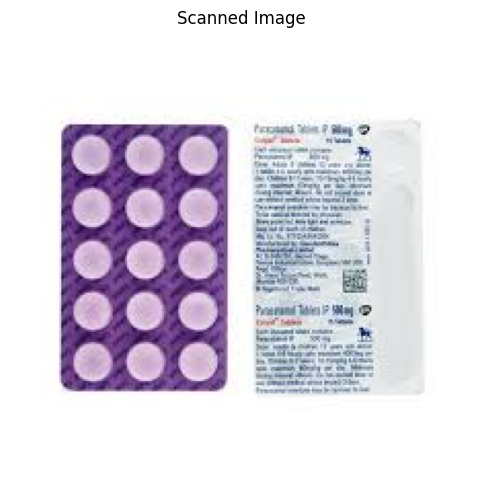


--- 🔍 Detected Text ---

🔴 Testing FAKE Medicine:
Scanning text... 


c:\Users\royla\OneDrive\Desktop\Fake medicine detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


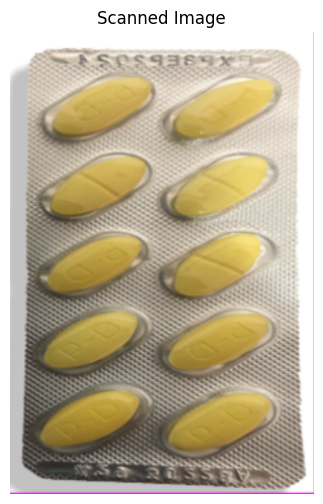


--- 🔍 Detected Text ---


In [3]:
# Cell 3: OCR Function & Visualisation

def detect_text(image_path):
    
    img = cv2.imread(image_path)
    
    if img is None:
        print(f"Error: Image nahi khul rahi - {image_path}")
        return

    
    print(f"Scanning text... ")
    results = reader.readtext(img)
    
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # BGR se RGB convert
    plt.axis('off')
    plt.title("Scanned Image")
    plt.show()
    
   
    print("\n--- 🔍 Detected Text ---")
    extracted_text = []
    for (bbox, text, prob) in results:
        
        if prob > 0.3:
            print(f"Text: {text}  (Confidence: {prob:.2f})")
            extracted_text.append(text)
    
    return extracted_text




print("\n🟢 Testing REAL Medicine:")
real_images = os.listdir(real_path)
if real_images:
    
    detect_text(os.path.join(real_path, real_images[1]))


print("\n🔴 Testing FAKE Medicine:")
fake_images = os.listdir(fake_path)
if fake_images:
    
    detect_text(os.path.join(fake_path, fake_images[0]))

In [ ]:
import pandas as pd
from tqdm import tqdm 

dataset = []

def process_folder(folder_path, label, limit=50):
    print(f"\n📂 Processing {label} folder (Limit: {limit} images)...")
    
    all_files = os.listdir(folder_path)
    image_files = [f for f in all_files if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    for file_name in tqdm(image_files[:limit]):
        full_path = os.path.join(folder_path, file_name)
        
        try:
            img = cv2.imread(full_path)
            
            text_results = reader.readtext(img, detail=0) 
            
            full_text = " ".join(text_results)
            
            dataset.append({
                "Filename": file_name,
                "Text": full_text,
                "Label": label
            })
            
        except Exception as e:
            print(f"Skipping {file_name}: {e}")

process_folder(real_path, label="Real", limit=50)


process_folder(fake_path, label="Fake", limit=50)

df = pd.DataFrame(dataset)

df.to_csv("medicine_dataset.csv", index=False)

print("\n✅ Processing Complete!")
print(f"Total Images Processed: {len(df)}")
print("Data 'medicine_dataset.csv'")

df.head()


📂 Processing Real folder (Limit: 50 images)...


  2%|▏         | 1/50 [00:00<00:13,  3.71it/s]c:\Users\royla\OneDrive\Desktop\Fake medicine detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 50/50 [00:12<00:00,  4.03it/s]



📂 Processing Fake folder (Limit: 50 images)...


100%|██████████| 50/50 [01:13<00:00,  1.47s/it]


✅ Processing Complete!
Total Images Processed: 100
Data 'medicine_dataset.csv'


,Filename,Text,Label
0,images01.jpg,,Real
1,images02.jpg,Paracetamo Tablets IP 500 mg Calpol 500],Real
2,images03.jpg,Tobs5s|F naleeln llt telmmtu,Real
3,images04.jpg,Paracetamol Tablets SC0 Iiq Calpol& 1531 KeA T...,Real
4,images05.jpg,,Real


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

df_clean = df[df['Text'].str.strip() != ""].copy()

print(f"total data: {len(df_clean)} samples")

X_train, X_test, y_train, y_test = train_test_split(
    df_clean['Text'], 
    df_clean['Label'], 
    test_size=0.2, 
    random_state=42
)

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

print("🤖 Model training starts...")
model.fit(X_train, y_train)
print("✅ Training complete!")

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\n🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\n--- Detailed Report ---")
print(classification_report(y_test, predictions))

total data: 75 samples
🤖 Model training starts...
✅ Training complete!

🎯 Model Accuracy: 93.33%

--- Detailed Report ---
              precision    recall  f1-score   support

        Fake       0.89      1.00      0.94         8
        Real       1.00      0.86      0.92         7

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



In [4]:
def predict_medicine(text_from_ocr):
    prediction = model.predict([text_from_ocr])[0]
    probability = model.predict_proba([text_from_ocr]).max() * 100
    
    return prediction, probability

sample_text_fake = "Paracitamol 500mg Batch:X99 Exp:2026" 
sample_text_real = "Paracetamol 500mg Batch:A12 Exp:2025" 

pred_fake, prob_fake = predict_medicine(sample_text_fake)
pred_real, prob_real = predict_medicine(sample_text_real)

print(f"Test 1 Text: '{sample_text_fake}'")
print(f"👉 Prediction: {pred_fake} ({prob_fake:.2f}%)")
print("-" * 30)
print(f"Test 2 Text: '{sample_text_real}'")
print(f"👉 Prediction: {pred_real} ({prob_real:.2f}%)")

Test 1 Text: 'Paracitamol 500mg Batch:X99 Exp:2026'
👉 Prediction: Fake (58.33%)
------------------------------
Test 2 Text: 'Paracetamol 500mg Batch:A12 Exp:2025'
👉 Prediction: Fake (52.08%)


In [5]:
import joblib 

dataset = []

print(" Full Data Processing Starts....")

process_folder(real_path, label="Real", limit=None) 

process_folder(fake_path, label="Fake", limit=None)

df = pd.DataFrame(dataset)
df.to_csv("full_medicine_dataset.csv", index=False)
print(f"Data Processed! Total Images: {len(df)}")


df_clean = df[df['Text'].str.strip() != ""].copy()
X_train, X_test, y_train, y_test = train_test_split(df_clean['Text'], df_clean['Label'], test_size=0.2)


model = make_pipeline(TfidfVectorizer(), MultinomialNB())
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"New Model Accuracy: {acc * 100:.2f}%")

joblib.dump(model, 'medicine_model.pkl')
print(" Model saved as 'medicine_model.pkl'")

 Full Data Processing Starts....

📂 Processing Real folder (Limit: None images)...


  0%|          | 1/421 [00:00<01:25,  4.93it/s]c:\Users\royla\OneDrive\Desktop\Fake medicine detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 421/421 [02:11<00:00,  3.21it/s]



📂 Processing Fake folder (Limit: None images)...


100%|██████████| 240/240 [05:57<00:00,  1.49s/it] 

Data Processed! Total Images: 661
New Model Accuracy: 81.82%
 Model saved as 'medicine_model.pkl'


In [6]:
import os
import joblib

current_location = os.getcwd()
print(f"📍 folder:\n{current_location}")

file_path = os.path.join(current_location, 'medicine_model.pkl')

if os.path.exists(file_path):
    print("\n File is here.")
    print(f"File ka naam: medicine_model.pkl")
else:
    print("\n File is not here.")
    
    try:
        if 'model' in globals():
            print("\n⚙️ Model is inside memory ...")
            joblib.dump(model, 'medicine_model.pkl')
            print("✅ Ab save ho gayi! Folder refresh karke dekhein.")
        else:
            print("⚠️ Model memory mein nahi hai. Lagta hai aapne Training wala code run nahi kiya ya Notebook band kar di thi.")
            print("Upaya: Upar wala 'Step 1: Poora Data Process' code dobara run karein.")
    except:
        pass

📍 folder:
c:\Users\royla\OneDrive\Desktop\Fake medicine detector

 File is here.
File ka naam: medicine_model.pkl
